<a href="https://colab.research.google.com/github/abdullaawad/Data-Warehousing-Coursework/blob/main/DWCoursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install Package
!pip install yfinance
!pip install yahoofinancials


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=ecd61c14cfb500841c5f8e79e5740e5aa9e69a1fde01f77abda7b0a37a391862
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials


In [2]:
import pandas as pd
import yfinance as yf
import requests
from io import StringIO
from IPython.display import display
import yfinance as yf
from yahoofinancials import YahooFinancials
from datetime import datetime
from typing import dataclass_transform
import numpy as np

In [3]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

In [4]:
response = requests.get(url, headers=headers)
response.raise_for_status()

# Read all tables on the page
tables = pd.read_html(StringIO(response.text))

# Find the table that contains a 'Symbol' column
sp500_table = None
for table in tables:
    cols_lower = [str(c).lower() for c in table.columns]
    if "symbol" in cols_lower:
        sp500_table = table.copy()
        break

if sp500_table is None:
    raise ValueError("No table with a 'Symbol' column found on the page.")

# Standardise column name to 'Symbol'
for col in sp500_table.columns:
    if str(col).lower() == "symbol":
        symbol_col = col
        break

sp500_table.rename(columns={symbol_col: "Symbol"}, inplace=True)

# Clean tickers (BRK.B → BRK-B) for Yahoo Finance
sp500_table["Symbol"] = (
    sp500_table["Symbol"]
    .astype(str)
    .str.replace(".", "-", regex=False)
)

# FINAL LIST OF TICKERS
tickers = sp500_table["Symbol"].unique().tolist()

print("Number of tickers:", len(tickers))
display(sp500_table.head())


Number of tickers: 503


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [5]:
# Define a start date and End Date
start = '2022-01-01'
#setting End Date
end = '2025-01-01'
data_source='yahoo'
p = yf.download(tickers, start, end)

/tmp/ipykernel_5690/1067665984.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  p = yf.download(tickers, start, end)
[**********************88%*****************      ]  445 of 503 completedERROR:yfinance:Failed to get ticker 'FOX' reason: Failed to perform, curl: (35) Recv failure: Connection reset by peer. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
ERROR:yfinance:Failed to get ticker 'ECL' reason: Failed to perform, curl: (35) Recv failure: Connection reset by peer. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
ERROR:yfinance:['FOX']: ConnectionError('Failed to perform, curl: 

In [6]:
tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CASY',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 '

In [7]:
p

Price      Adj Close                Close                                      \
Ticker           FOX   Q SNDK           A        AAPL        ABBV        ABNB   
Date                                                                            
2022-01-03       NaN NaN  NaN  151.702164  178.103638  115.847198  172.679993   
2022-01-04       NaN NaN  NaN  146.573700  175.843246  115.624802  170.800003   
2022-01-05       NaN NaN  NaN  144.062729  171.165817  116.232162  162.250000   
2022-01-06       NaN NaN  NaN  144.566864  168.308487  115.684677  159.750000   
2022-01-07       NaN NaN  NaN  140.718079  168.474823  115.385284  166.050003   
...              ...  ..  ...         ...         ...         ...         ...   
2024-12-24       NaN NaN  NaN  134.457275  256.797211  172.530670  134.990005   
2024-12-26       NaN NaN  NaN  134.190506  257.612732  171.763870  135.320007   
2024-12-27       NaN NaN  NaN  133.904007  254.201385  170.623230  133.384995   
2024-12-30       NaN NaN  NaN  132.797546  250.829788  168.888367  131.809998   
2024-12-31       NaN NaN  NaN  132.963806  249.059448  170.326096  131.410004   

Price                                          ...   Volume                    \
Ticker             ABT       ACGL         ACN  ...       WY     WYNN      XEL   
Date                                           ...                              
2022-01-03  128.345993  42.362530  380.485321  ...  3831100  2437800  3501100   
2022-01-04  125.327507  42.914051  377.766296  ...  3089700  2292300  4197000   
2022-01-05  124.764427  42.410072  371.113495  ...  3737600  3439900  4166000   
2022-01-06  124.745949  42.657307  353.192322  ...  3315200  2583200  2296000   
2022-01-07  125.133652  42.856995  346.418121  ...  3309900  1720400  2673100   
...                ...        ...         ...  ...      ...      ...      ...   
2024-12-24  112.058296  92.669998  353.541473  ...  1780100   692800   943900   
2024-12-26  112.556282  92.930000  352.368317  ...  1736500  1218900  1394900   
2024-12-27  112.282867  92.339996  348.213348  ...  2320500  1086700  2015000   
2024-12-30  110.144432  91.889999  344.605927  ...  2914700  2180100  2642900   
2024-12-31  110.447136  92.349998  343.921600  ...  3125200  1612600  2143800   

Price                                                                       
Ticker           XOM      XYL       XYZ      YUM      ZBH    ZBRA      ZTS  
Date                                                                        
2022-01-03  24282400   759100   7315700  1251400  1184809  272600  2772700  
2022-01-04  38584000   925400  14768500   935900  1400800  346000  4664000  
2022-01-05  34033300  1090200  17546200   977900  1895715  403700  4749400  
2022-01-06  30668500   703400  16244200   862400  1088813  338300  3103400  
2022-01-07  23985400   765000   9426000   833700  1690230  432800  2206500  
...              ...      ...       ...      ...      ...     ...      ...  
2024-12-24   7807000   379300   2197700   533000   458600   88700  1023600  
2024-12-26   9652400   575700   2991100  1040900  1277300  140100  2167200  
2024-12-27  11943900   552400   4140800  1146300   743400  287200  1800100  
2024-12-30  11080800   586800   5383800  1144600  1532000  211300  1531400  
2024-12-31  12387800   641600   4989400  1217100   683300  327900  1327400  

[753 rows x 2518 columns]

In [8]:
data = p.dropna(axis=1, how='all')
data

Price            Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702164  178.103638  115.847198  172.679993  128.345993   
2022-01-04  146.573700  175.843246  115.624802  170.800003  125.327507   
2022-01-05  144.062729  171.165817  116.232162  162.250000  124.764427   
2022-01-06  144.566864  168.308487  115.684677  159.750000  124.745949   
2022-01-07  140.718079  168.474823  115.385284  166.050003  125.133652   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457275  256.797211  172.530670  134.990005  112.058296   
2024-12-26  134.190506  257.612732  171.763870  135.320007  112.556282   
2024-12-27  133.904007  254.201385  170.623230  133.384995  112.282867   
2024-12-30  132.797546  250.829788  168.888367  131.809998  110.144432   
2024-12-31  132.963806  249.059448  170.326096  131.410004  110.447136   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  380.485321  564.369995  164.526474  60.037273  ...   
2022-01-04  42.914051  377.766296  554.000000  163.040436  61.151524  ...   
2022-01-05  42.410072  371.113495  514.429993  160.523575  60.673988  ...   
2022-01-06  42.657307  353.192322  514.119995  161.034424  61.213425  ...   
2022-01-07  42.856995  346.418121  510.700012  156.808624  61.735188  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  353.541473  447.940002  213.882050  48.364082  ...   
2024-12-26  92.930000  352.368317  450.160004  213.852631  48.344982  ...   
2024-12-27  92.339996  348.213348  446.480011  212.803284  48.316322  ...   
2024-12-30  91.889999  344.605927  445.799988  208.458755  47.829144  ...   
2024-12-31  92.349998  343.921600  444.679993  208.360703  48.259007  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 2500 columns]

In [9]:
data = data['Close']
data

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702164,178.103638,115.847198,172.679993,128.345993,42.362530,380.485321,564.369995,164.526474,60.037273,...,33.979382,85.125763,59.164783,54.760239,110.957489,164.029999,125.887245,120.797714,583.900024,224.021240
2022-01-04,146.573700,175.843246,115.624802,170.800003,125.327507,42.914051,377.766296,554.000000,163.040436,61.151524,...,34.414909,84.854210,59.539242,56.820004,112.134552,156.330002,126.560303,122.023186,587.599976,215.492294
2022-01-05,144.062729,171.165817,116.232162,162.250000,124.764427,42.410072,371.113495,514.429993,160.523575,60.673988,...,33.560612,81.711823,60.122700,57.526691,110.606277,143.490005,124.955933,121.620972,558.179993,207.298386
2022-01-06,144.566864,168.308487,115.684677,159.750000,124.745949,42.657307,353.192322,514.119995,161.034424,61.213425,...,33.828625,82.090065,59.652454,58.879761,110.454376,144.660004,126.246803,120.610626,555.159973,208.121597
2022-01-07,140.718079,168.474823,115.385284,166.050003,125.133652,42.856995,346.418121,510.700012,156.808624,61.735188,...,33.786747,82.002800,60.174953,59.362354,109.571602,141.539993,124.799187,119.880959,530.859985,202.062286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457275,256.797211,172.530670,134.990005,112.058296,92.669998,353.541473,447.940002,213.882050,48.364082,...,27.116613,87.733513,65.030983,101.953659,116.360306,91.080002,131.828522,105.724754,395.440002,161.848907
2024-12-26,134.190506,257.612732,171.763870,135.320007,112.556282,92.930000,352.368317,450.160004,213.852631,48.344982,...,27.030256,88.257271,65.002380,102.039902,116.675453,91.480003,132.805023,105.675476,396.850006,162.654724
2024-12-27,133.904007,254.201385,170.623230,133.384995,112.282867,92.339996,348.213348,446.480011,212.803284,48.316322,...,26.857538,87.634689,64.964249,102.030319,115.749695,88.970001,132.053085,105.301056,389.070007,161.750641


In [10]:
data.dropna(axis=1, how='all')

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702164,178.103638,115.847198,172.679993,128.345993,42.362530,380.485321,564.369995,164.526474,60.037273,...,33.979382,85.125763,59.164783,54.760239,110.957489,164.029999,125.887245,120.797714,583.900024,224.021240
2022-01-04,146.573700,175.843246,115.624802,170.800003,125.327507,42.914051,377.766296,554.000000,163.040436,61.151524,...,34.414909,84.854210,59.539242,56.820004,112.134552,156.330002,126.560303,122.023186,587.599976,215.492294
2022-01-05,144.062729,171.165817,116.232162,162.250000,124.764427,42.410072,371.113495,514.429993,160.523575,60.673988,...,33.560612,81.711823,60.122700,57.526691,110.606277,143.490005,124.955933,121.620972,558.179993,207.298386
2022-01-06,144.566864,168.308487,115.684677,159.750000,124.745949,42.657307,353.192322,514.119995,161.034424,61.213425,...,33.828625,82.090065,59.652454,58.879761,110.454376,144.660004,126.246803,120.610626,555.159973,208.121597
2022-01-07,140.718079,168.474823,115.385284,166.050003,125.133652,42.856995,346.418121,510.700012,156.808624,61.735188,...,33.786747,82.002800,60.174953,59.362354,109.571602,141.539993,124.799187,119.880959,530.859985,202.062286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.457275,256.797211,172.530670,134.990005,112.058296,92.669998,353.541473,447.940002,213.882050,48.364082,...,27.116613,87.733513,65.030983,101.953659,116.360306,91.080002,131.828522,105.724754,395.440002,161.848907
2024-12-26,134.190506,257.612732,171.763870,135.320007,112.556282,92.930000,352.368317,450.160004,213.852631,48.344982,...,27.030256,88.257271,65.002380,102.039902,116.675453,91.480003,132.805023,105.675476,396.850006,162.654724
2024-12-27,133.904007,254.201385,170.623230,133.384995,112.282867,92.339996,348.213348,446.480011,212.803284,48.316322,...,26.857538,87.634689,64.964249,102.030319,115.749695,88.970001,132.053085,105.301056,389.070007,161.750641


In [11]:
data.head(10)

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,151.702164,178.103638,115.847198,172.679993,128.345993,42.362530,380.485321,564.369995,164.526474,60.037273,...,33.979382,85.125763,59.164783,54.760239,110.957489,164.029999,125.887245,120.797714,583.900024,224.021240
2022-01-04,146.573700,175.843246,115.624802,170.800003,125.327507,42.914051,377.766296,554.000000,163.040436,61.151524,...,34.414909,84.854210,59.539242,56.820004,112.134552,156.330002,126.560303,122.023186,587.599976,215.492294
2022-01-05,144.062729,171.165817,116.232162,162.250000,124.764427,42.410072,371.113495,514.429993,160.523575,60.673988,...,33.560612,81.711823,60.122700,57.526691,110.606277,143.490005,124.955933,121.620972,558.179993,207.298386
2022-01-06,144.566864,168.308487,115.684677,159.750000,124.745949,42.657307,353.192322,514.119995,161.034424,61.213425,...,33.828625,82.090065,59.652454,58.879761,110.454376,144.660004,126.246803,120.610626,555.159973,208.121597
2022-01-07,140.718079,168.474823,115.385284,166.050003,125.133652,42.856995,346.418121,510.700012,156.808624,61.735188,...,33.786747,82.002800,60.174953,59.362354,109.571602,141.539993,124.799187,119.880959,530.859985,202.062286
2022-01-10,140.727783,168.494415,116.677040,160.710007,124.856766,43.760349,348.520477,525.830017,158.257462,61.841297,...,33.627609,79.694481,60.836800,59.009018,108.460976,144.479996,123.056549,118.711624,535.409973,203.507736
2022-01-11,142.162582,171.322403,117.173187,168.610001,125.262894,44.093163,350.491974,529.890015,161.257278,62.327694,...,34.113388,82.730202,59.739536,61.491070,110.292999,148.429993,120.474808,120.096130,538.570007,203.699158
2022-01-12,144.944962,171.762787,117.446930,169.539993,123.435173,44.188255,353.349243,532.369995,161.368713,62.274624,...,34.381409,83.215126,59.730816,61.310097,110.283516,145.470001,119.082489,117.476791,538.440002,203.708755
2022-01-13,140.737473,168.494415,115.407104,166.000000,120.100327,44.445000,338.529083,516.900024,157.681641,62.699104,...,34.892307,81.692436,60.105286,60.870552,108.612839,136.949997,118.769012,119.806129,525.799988,198.147232


# ***Daily Returns:***

In [12]:
#daily returns
daily_returns = data.pct_change()
daily_returns = daily_returns.iloc[1:]
daily_returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.033806,-0.012691,-0.001920,-0.010887,-0.023518,0.013019,-0.007146,-0.018374,-0.009032,0.018559,...,0.012817,-0.003190,0.006329,0.037614,0.010608,-0.046943,0.005347,0.010145,0.006337,-0.038072
2022-01-05,-0.017131,-0.026600,0.005253,-0.050059,-0.004493,-0.011744,-0.017611,-0.071426,-0.015437,-0.007809,...,-0.024823,-0.037033,0.009800,0.012437,-0.013629,-0.082134,-0.012677,-0.003296,-0.050068,-0.038024
2022-01-06,0.003499,-0.016693,-0.004710,-0.015408,-0.000148,0.005830,-0.048290,-0.000603,0.003182,0.008891,...,0.007986,0.004629,-0.007821,0.023521,-0.001373,0.008154,0.010331,-0.008307,-0.005410,0.003971
2022-01-07,-0.026623,0.000988,-0.002588,0.039437,0.003108,0.004681,-0.019180,-0.006652,-0.026242,0.008524,...,-0.001238,-0.001063,0.008759,0.008196,-0.007992,-0.021568,-0.011467,-0.006050,-0.043771,-0.029114
2022-01-10,0.000069,0.000116,0.011195,-0.032159,-0.002213,0.021078,0.006069,0.029626,0.009240,0.001719,...,-0.004710,-0.028149,0.010999,-0.005952,-0.010136,0.020772,-0.013964,-0.009754,0.008571,0.007153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,0.011144,0.011478,0.009025,0.003494,0.003937,0.006298,0.007972,0.002686,0.014891,0.004364,...,0.006410,0.007604,0.007236,0.000941,0.005446,0.020047,0.008516,0.004494,0.012262,0.002557
2024-12-26,-0.001984,0.003176,-0.004444,0.002445,0.004444,0.002806,-0.003318,0.004956,-0.000138,-0.000395,...,-0.003185,0.005970,-0.000440,0.000846,0.002708,0.004392,0.007407,-0.000466,0.003566,0.004979
2024-12-27,-0.002135,-0.013242,-0.006641,-0.014300,-0.002429,-0.006349,-0.011792,-0.008175,-0.004907,-0.000593,...,-0.006390,-0.007054,-0.000587,-0.000094,-0.007934,-0.027438,-0.005662,-0.003543,-0.019604,-0.005558


In [13]:
dr_mean = daily_returns.mean()
dr_mean.name = 'Average Daily returns'
dr_mean

,Average Daily returns
Ticker,
A,-0.000002
AAPL,0.000591
ABBV,0.000610
ABNB,0.000074
ABT,-0.000106
...,...
XYZ,-0.000034
YUM,0.000126
ZBH,-0.000076


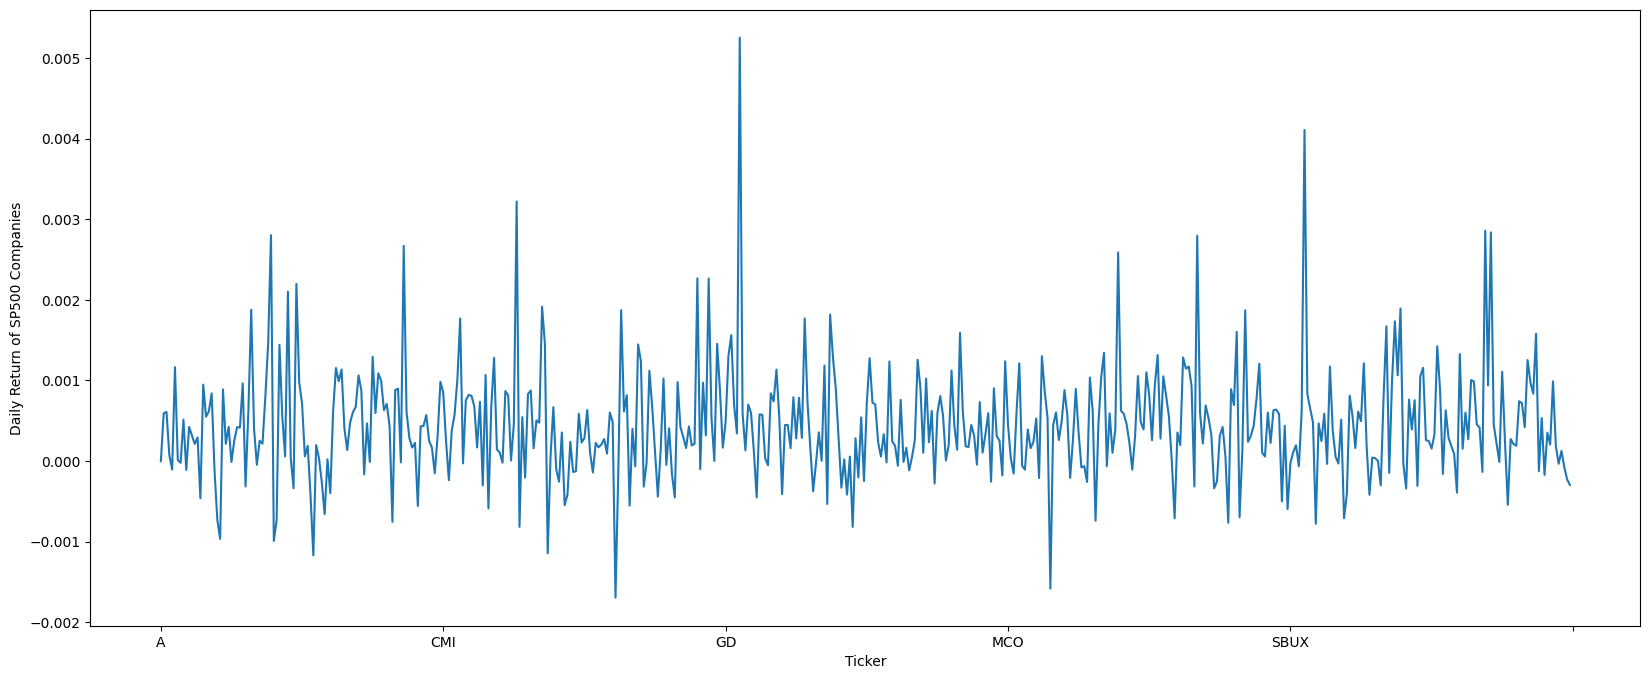

In [14]:
from matplotlib import pyplot as plt
plt.figure(figsize=(20,8))
dr_mean.plot()
plt.ylabel("Daily Return of SP500 Companies")
plt.show()

# ***Beta Calculation:***

In [15]:
def fetch_data(tickers, index='^GSPC', start=None, end=None, interval='1d'):
    all_tickers = tickers + [index]
    df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
    return df

In [16]:
def calculate_ratios(returns, benchmark_returns, risk_free_rate=0.04/252):
    excess = returns - risk_free_rate
    downside = excess[excess < 0]

    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)
    return beta

In [17]:
def build_screener(tickers, index='^GSPC', start=None, end=None, risk_free_rate=0.04/252):
    df = fetch_data(tickers, index=index, start=start, end=end)
    benchmark = df[index].pct_change().dropna()
    results = []

    for ticker in tickers:
        ret = df[ticker].pct_change().dropna()
        aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()
        beta = calculate_ratios(aligned[ticker], aligned[index], risk_free_rate)
        results.append({'Ticker': ticker, 'Beta': beta})

    return pd.DataFrame(results).sort_values('Beta', ascending=False)

In [18]:
import numpy as np
df = build_screener(tickers, index='^GSPC', start=start, end=end)
print(df)

/tmp/ipykernel_5690/2721606737.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(all_tickers, start=start, end=end, interval=interval)['Close']
[*********************100%***********************]  504 of 504 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')
/tmp/ipykernel_5690/3292031660.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = df[ticker].pct_change().dropna()
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/

    Ticker      Beta
88    CVNA  3.298454
118   COIN  2.964902
67     XYZ  2.548173
344   NVDA  2.271537
40     APP  2.264945
..     ...       ...
414    SJM  0.196851
83     CPB  0.133843
219    GIS  0.133427
386      Q       NaN
405   SNDK       NaN

[503 rows x 2 columns]


In [19]:
df

,Ticker,Beta
88,CVNA,3.298454
118,COIN,2.964902
67,XYZ,2.548173
344,NVDA,2.271537
40,APP,2.264945
...,...,...
414,SJM,0.196851
83,CPB,0.133843
219,GIS,0.133427
386,Q,NaN


In [20]:
df.dropna()

,Ticker,Beta
88,CVNA,3.298454
118,COIN,2.964902
67,XYZ,2.548173
344,NVDA,2.271537
40,APP,2.264945
...,...,...
292,LMT,0.244189
238,HRL,0.236922
414,SJM,0.196851
83,CPB,0.133843


In [21]:
import statistics
Annual_vol = daily_returns.std() * np.sqrt(252)
Annual_vol.name = 'Annual Volatility'
Annual_vol

,Annual Volatility
Ticker,
A,0.296259
AAPL,0.270935
ABBV,0.219958
ABNB,0.467875
ABT,0.217839
...,...
XYZ,0.653825
YUM,0.191335
ZBH,0.245157


In [22]:
all_dim = df.merge(Annual_vol, left_on='Ticker', right_index=True)
all_dim = all_dim.merge(dr_mean, left_on='Ticker', right_index=True)
all_dim

,Ticker,Beta,Annual Volatility,Average Daily returns
88,CVNA,3.298454,1.341039,0.003219
118,COIN,2.964902,0.953848,0.001768
67,XYZ,2.548173,0.653825,-0.000034
344,NVDA,2.271537,0.552710,0.002588
40,APP,2.264945,0.788374,0.002802
...,...,...,...,...
292,LMT,0.244189,0.209530,0.000611
238,HRL,0.236922,0.232603,-0.000376
414,SJM,0.196851,0.219994,-0.000065
83,CPB,0.133843,0.223119,0.000168


In [23]:
all_dim

,Ticker,Beta,Annual Volatility,Average Daily returns
88,CVNA,3.298454,1.341039,0.003219
118,COIN,2.964902,0.953848,0.001768
67,XYZ,2.548173,0.653825,-0.000034
344,NVDA,2.271537,0.552710,0.002588
40,APP,2.264945,0.788374,0.002802
...,...,...,...,...
292,LMT,0.244189,0.209530,0.000611
238,HRL,0.236922,0.232603,-0.000376
414,SJM,0.196851,0.219994,-0.000065
83,CPB,0.133843,0.223119,0.000168


In [24]:
all_dim_100 = all_dim.iloc[:100]

In [25]:
from matplotlib import pyplot as plt
import seaborn as sns

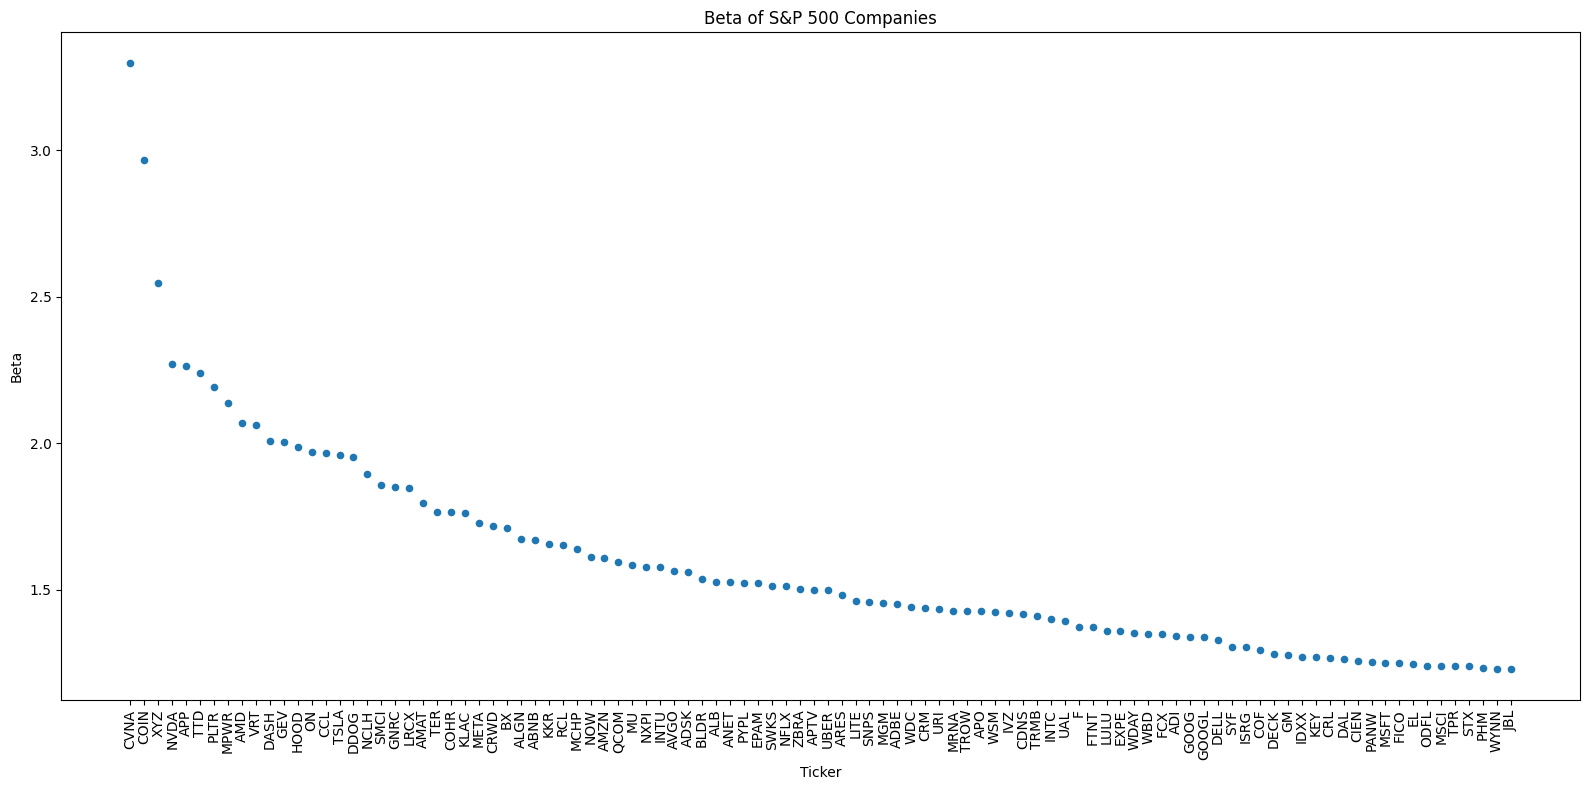

In [26]:
all_dim_100.plot(x='Ticker', y=['Beta'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Beta')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

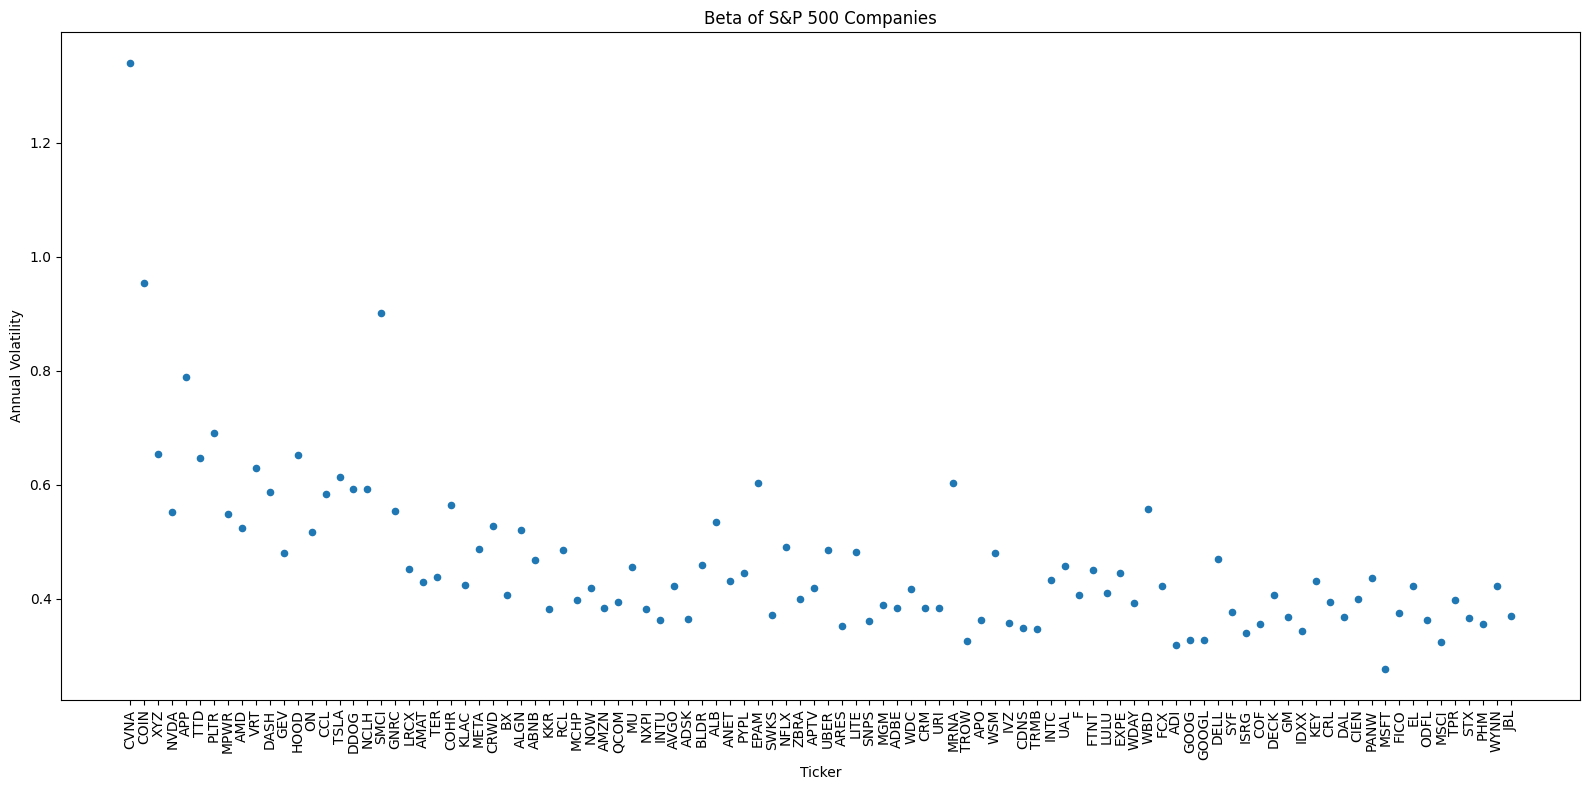

In [27]:
all_dim_100.plot(x='Ticker', y=['Annual Volatility'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Annual Volatility')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

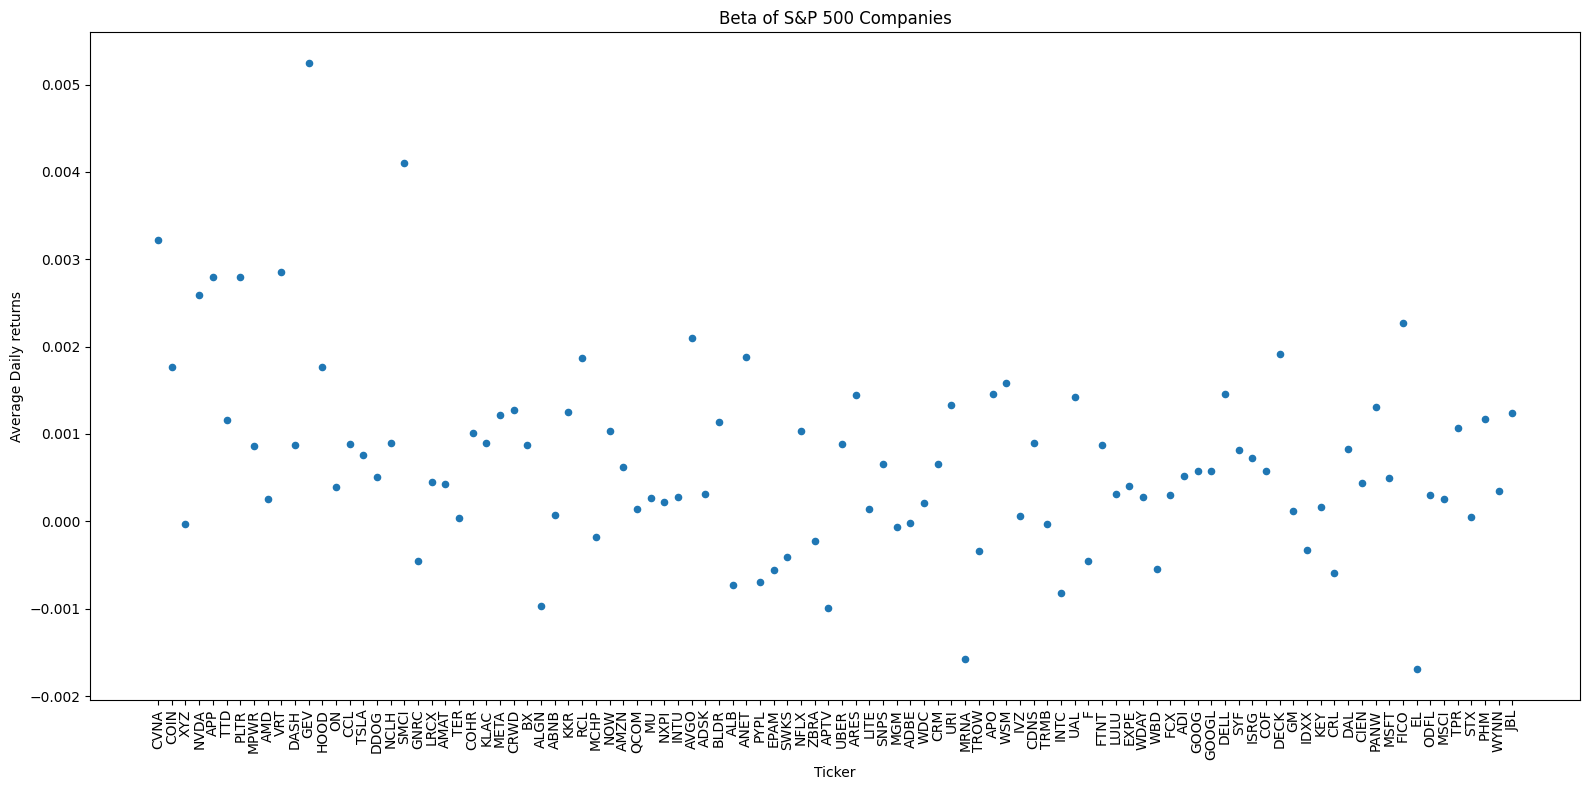

In [28]:
all_dim_100.plot(x='Ticker', y=['Average Daily returns'], kind='scatter', figsize=(16,8))
plt.title('Beta of S&P 500 Companies')
plt.xlabel('Ticker')
plt.ylabel('Average Daily returns')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## **Part B: Customer Segmentation:**

In [34]:
print(all_dim.index.tolist())
print(all_dim[['Beta', 'Annual Volatility', 'Average Daily returns']].isna().sum())

[88, 118, 67, 344, 40, 446, 357, 321, 6, 472, 157, 215, 397, 351, 86, 439, 143, 341, 426, 217, 284, 39, 438, 117, 279, 310, 136, 66, 15, 11, 278, 402, 314, 410, 22, 384, 315, 346, 258, 73, 50, 77, 13, 45, 362, 176, 413, 330, 500, 41, 456, 44, 296, 428, 313, 5, 490, 404, 462, 318, 431, 37, 492, 260, 81, 451, 253, 460, 204, 205, 295, 189, 495, 483, 210, 34, 20, 19, 147, 427, 259, 84, 145, 220, 248, 273, 98, 148, 105, 358, 316, 195, 183, 349, 327, 433, 408, 382, 496, 265, 359, 252, 387, 55, 121, 209, 38, 274, 371, 178, 65, 150, 262, 287, 453, 30, 291, 398, 63, 223, 343, 440, 251, 160, 87, 422, 111, 420, 312, 33, 241, 335, 436, 135, 360, 288, 200, 70, 132, 92, 383, 380, 363, 26, 234, 423, 239, 323, 452, 212, 193, 4, 102, 128, 240, 285, 449, 130, 302, 165, 324, 69, 62, 300, 164, 498, 393, 303, 489, 339, 79, 201, 235, 329, 225, 396, 244, 93, 332, 269, 442, 206, 482, 333, 213, 9, 345, 388, 377, 372, 448, 126, 7, 477, 110, 199, 435, 226, 353, 476, 14, 370, 163, 421, 485, 16, 412, 455, 167, 214

In [37]:
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform(all_dim[['Beta', 'Annual Volatility', 'Average Daily returns']])
scaled_df = pd.DataFrame(scaled, columns=['Beta', 'Annual Volatility', 'Average Daily returns'], index=all_dim.index)
all_dim_scaled = all_dim.copy()
all_dim_scaled[['Beta', 'Annual Volatility', 'Average Daily returns']] = scaled_df
all_dim_scaled

,Ticker,Beta,Annual Volatility,Average Daily returns
88,CVNA,5.424153,8.963470,3.965134
118,COIN,4.655234,5.582665,1.888782
67,XYZ,3.694574,2.962982,-0.689055
344,NVDA,3.056861,2.080083,3.062127
40,APP,3.041665,4.137818,3.367853
...,...,...,...,...
292,LMT,-1.616662,-0.916431,0.233378
238,HRL,-1.633415,-0.714965,-1.178757
414,SJM,-1.725787,-0.825062,-0.733600
83,CPB,-1.871037,-0.797777,-0.399988


In [38]:
print(scaled_df.index.tolist())
print(scaled_df.isna().sum())

[88, 118, 67, 344, 40, 446, 357, 321, 6, 472, 157, 215, 397, 351, 86, 439, 143, 341, 426, 217, 284, 39, 438, 117, 279, 310, 136, 66, 15, 11, 278, 402, 314, 410, 22, 384, 315, 346, 258, 73, 50, 77, 13, 45, 362, 176, 413, 330, 500, 41, 456, 44, 296, 428, 313, 5, 490, 404, 462, 318, 431, 37, 492, 260, 81, 451, 253, 460, 204, 205, 295, 189, 495, 483, 210, 34, 20, 19, 147, 427, 259, 84, 145, 220, 248, 273, 98, 148, 105, 358, 316, 195, 183, 349, 327, 433, 408, 382, 496, 265, 359, 252, 387, 55, 121, 209, 38, 274, 371, 178, 65, 150, 262, 287, 453, 30, 291, 398, 63, 223, 343, 440, 251, 160, 87, 422, 111, 420, 312, 33, 241, 335, 436, 135, 360, 288, 200, 70, 132, 92, 383, 380, 363, 26, 234, 423, 239, 323, 452, 212, 193, 4, 102, 128, 240, 285, 449, 130, 302, 165, 324, 69, 62, 300, 164, 498, 393, 303, 489, 339, 79, 201, 235, 329, 225, 396, 244, 93, 332, 269, 442, 206, 482, 333, 213, 9, 345, 388, 377, 372, 448, 126, 7, 477, 110, 199, 435, 226, 353, 476, 14, 370, 163, 421, 485, 16, 412, 455, 167, 214

In [39]:
print(all_dim_scaled.index.tolist())
print(all_dim_scaled.isna().sum())

[88, 118, 67, 344, 40, 446, 357, 321, 6, 472, 157, 215, 397, 351, 86, 439, 143, 341, 426, 217, 284, 39, 438, 117, 279, 310, 136, 66, 15, 11, 278, 402, 314, 410, 22, 384, 315, 346, 258, 73, 50, 77, 13, 45, 362, 176, 413, 330, 500, 41, 456, 44, 296, 428, 313, 5, 490, 404, 462, 318, 431, 37, 492, 260, 81, 451, 253, 460, 204, 205, 295, 189, 495, 483, 210, 34, 20, 19, 147, 427, 259, 84, 145, 220, 248, 273, 98, 148, 105, 358, 316, 195, 183, 349, 327, 433, 408, 382, 496, 265, 359, 252, 387, 55, 121, 209, 38, 274, 371, 178, 65, 150, 262, 287, 453, 30, 291, 398, 63, 223, 343, 440, 251, 160, 87, 422, 111, 420, 312, 33, 241, 335, 436, 135, 360, 288, 200, 70, 132, 92, 383, 380, 363, 26, 234, 423, 239, 323, 452, 212, 193, 4, 102, 128, 240, 285, 449, 130, 302, 165, 324, 69, 62, 300, 164, 498, 393, 303, 489, 339, 79, 201, 235, 329, 225, 396, 244, 93, 332, 269, 442, 206, 482, 333, 213, 9, 345, 388, 377, 372, 448, 126, 7, 477, 110, 199, 435, 226, 353, 476, 14, 370, 163, 421, 485, 16, 412, 455, 167, 214

In [45]:
print(all_dim_scaled[all_dim_scaled['Ticker'].isin(['ZBH', 'ZTS'])])

    Ticker      Beta  Annual Volatility  Average Daily returns
502    ZTS -0.063756          -0.344633              -1.064579
501    ZBH -0.479500          -0.605349              -0.749089


In [40]:
print(all_dim_scaled[all_dim_scaled.isna().any(axis=1)])

Empty DataFrame
Columns: [Ticker, Beta, Annual Volatility, Average Daily returns]
Index: []


<function matplotlib.pyplot.show(close=None, block=None)>

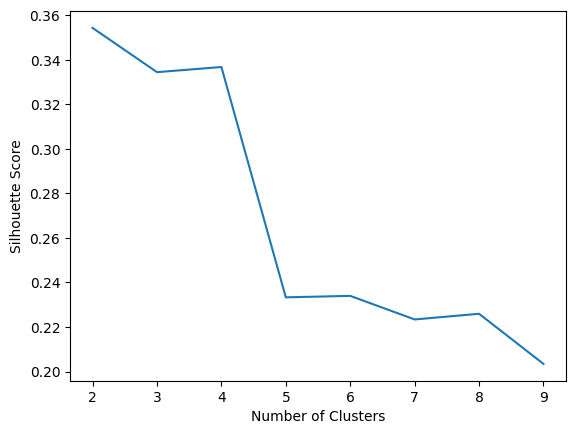

In [31]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
#assigning Beta column to X
X = all_dim_scaled[['Beta', 'Annual Volatility', 'Average Daily returns']]
#testing number of cluster from 2 to 10 and collecting the silhouette
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for n_clusters in range_n_clusters:
  agglom = AgglomerativeClustering(n_clusters=n_clusters)
  agglom.fit(X)
  labels = agglom.labels_
  scores.append(silhouette_score(X, labels))
#looking at the scores, and their average/mean
scores
average = sum(scores)/len(scores)
average
#graphing
plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show

Cluster 1 has 179 observations
Cluster 2 has 321 observations


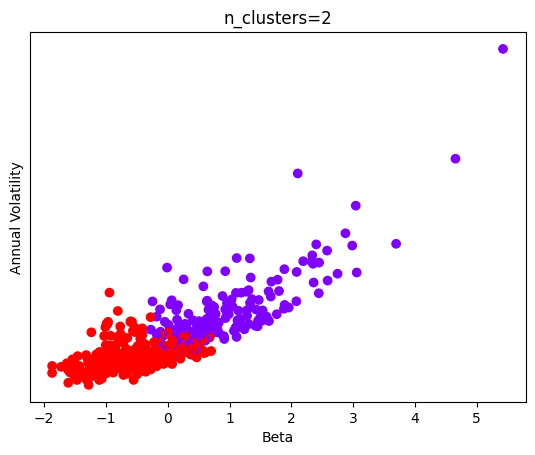

Cluster 1 has 160 observations
Cluster 2 has 321 observations
Cluster 3 has 19 observations


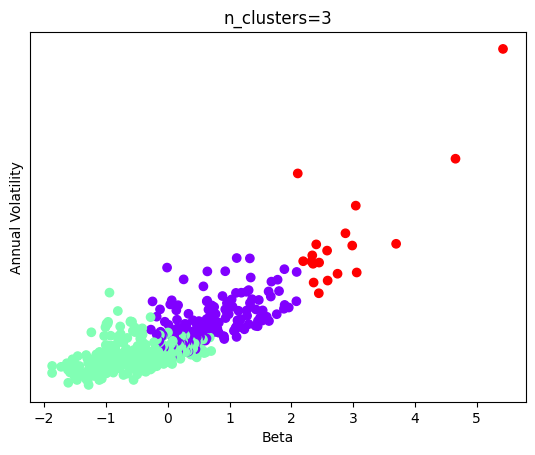

Cluster 1 has 321 observations
Cluster 2 has 95 observations
Cluster 3 has 19 observations
Cluster 4 has 65 observations


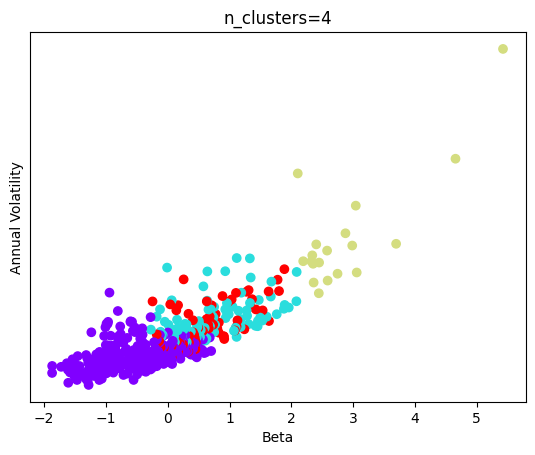

Cluster 1 has 19 observations
Cluster 2 has 95 observations
Cluster 3 has 182 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations


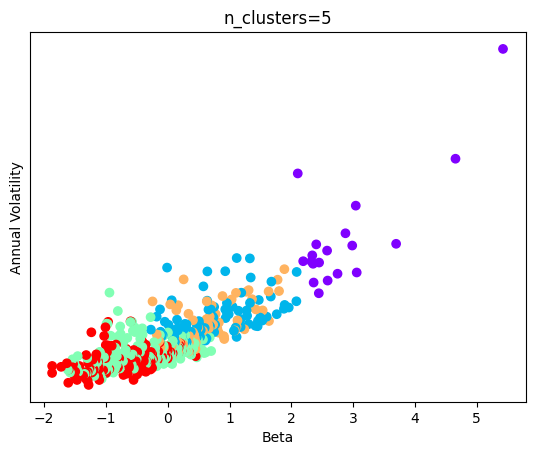

Cluster 1 has 182 observations
Cluster 2 has 95 observations
Cluster 3 has 8 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations


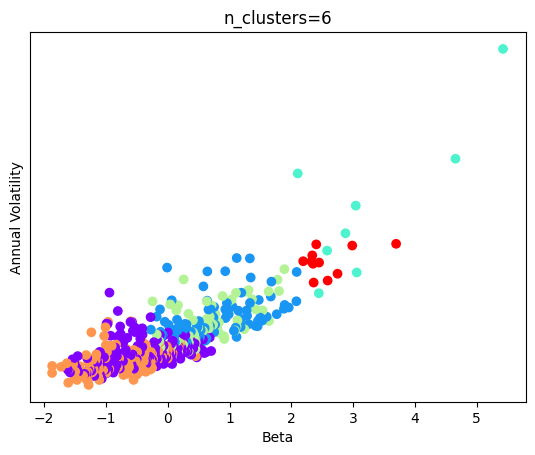

Cluster 1 has 8 observations
Cluster 2 has 95 observations
Cluster 3 has 119 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations


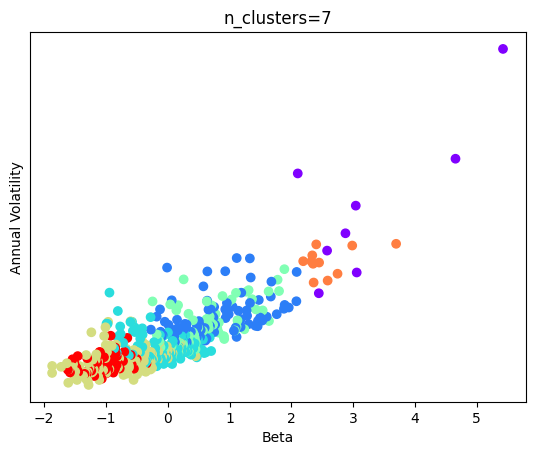

Cluster 1 has 95 observations
Cluster 2 has 65 observations
Cluster 3 has 119 observations
Cluster 4 has 6 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations
Cluster 8 has 2 observations


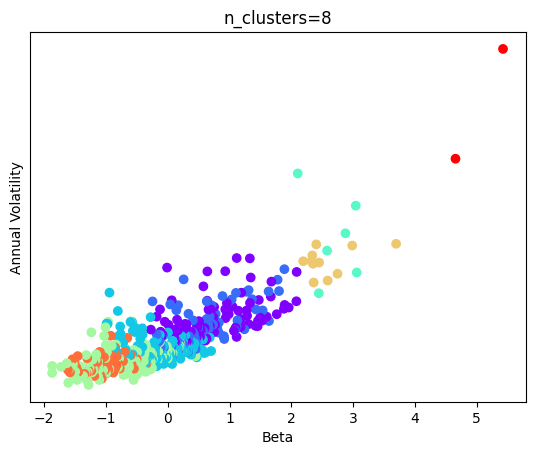

Cluster 1 has 65 observations
Cluster 2 has 139 observations
Cluster 3 has 119 observations
Cluster 4 has 6 observations
Cluster 5 has 50 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations
Cluster 8 has 2 observations
Cluster 9 has 45 observations


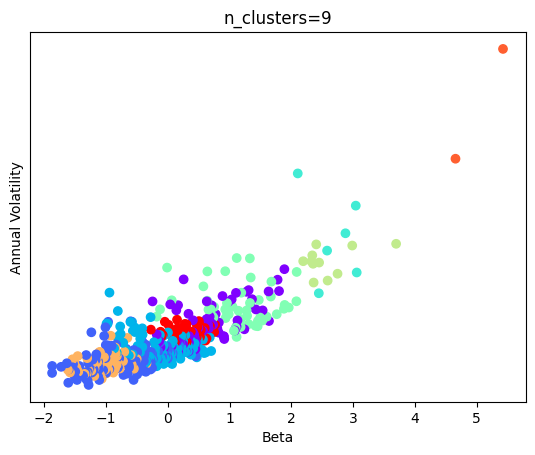

In [52]:
for n_clusters in range_n_clusters:
  model = AgglomerativeClustering(n_clusters=n_clusters)
  labels = model.fit_predict(X)
  plt.scatter(all_dim_scaled['Beta'], all_dim_scaled['Annual Volatility'], c=labels, cmap='rainbow')
  plt.xlabel('Beta')
  plt.ylabel('Annual Volatility')
  plt.title(f"n_clusters={n_clusters}")
  cluster_counts = np.bincount(labels)
  for i in range(n_clusters):
    print(f"Cluster {i+1} has {cluster_counts[i]} observations")
  plt.yticks([])
  plt.show()

Cluster 1 has 179 observations
Cluster 2 has 321 observations


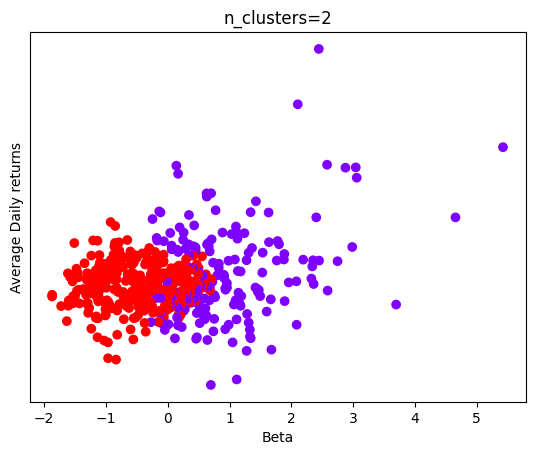

Cluster 1 has 160 observations
Cluster 2 has 321 observations
Cluster 3 has 19 observations


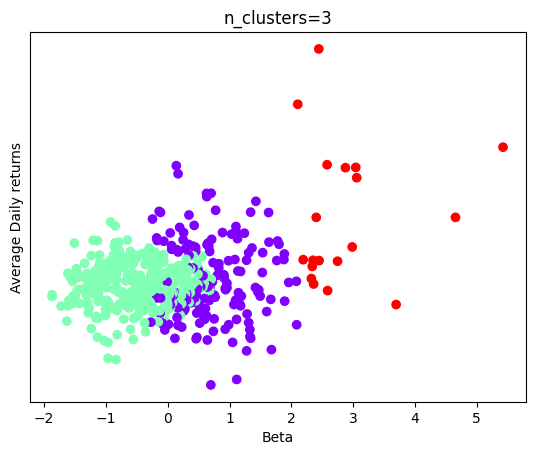

Cluster 1 has 321 observations
Cluster 2 has 95 observations
Cluster 3 has 19 observations
Cluster 4 has 65 observations


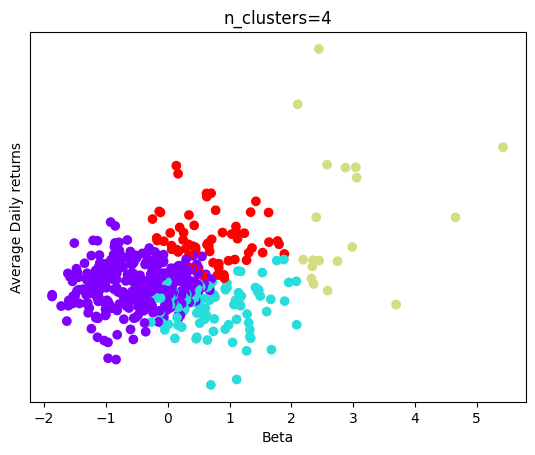

Cluster 1 has 19 observations
Cluster 2 has 95 observations
Cluster 3 has 182 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations


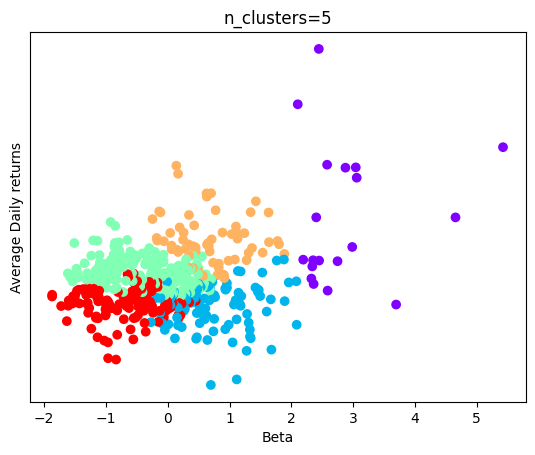

Cluster 1 has 182 observations
Cluster 2 has 95 observations
Cluster 3 has 8 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations


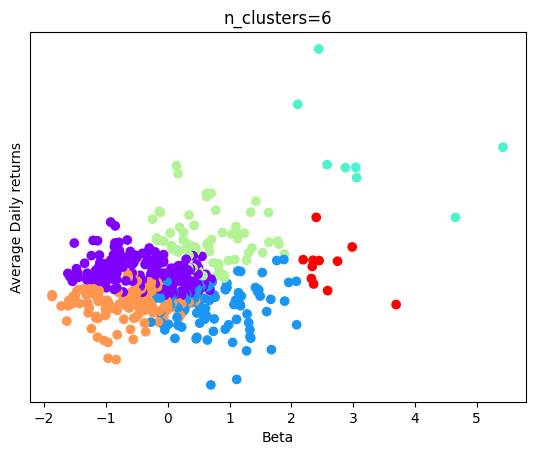

Cluster 1 has 8 observations
Cluster 2 has 95 observations
Cluster 3 has 119 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations


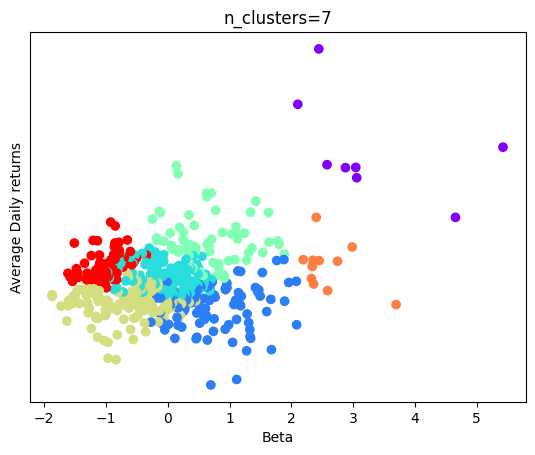

Cluster 1 has 95 observations
Cluster 2 has 65 observations
Cluster 3 has 119 observations
Cluster 4 has 6 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations
Cluster 8 has 2 observations


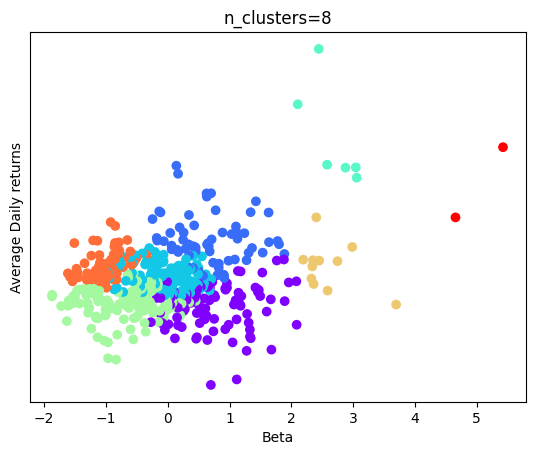

Cluster 1 has 65 observations
Cluster 2 has 139 observations
Cluster 3 has 119 observations
Cluster 4 has 6 observations
Cluster 5 has 50 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations
Cluster 8 has 2 observations
Cluster 9 has 45 observations


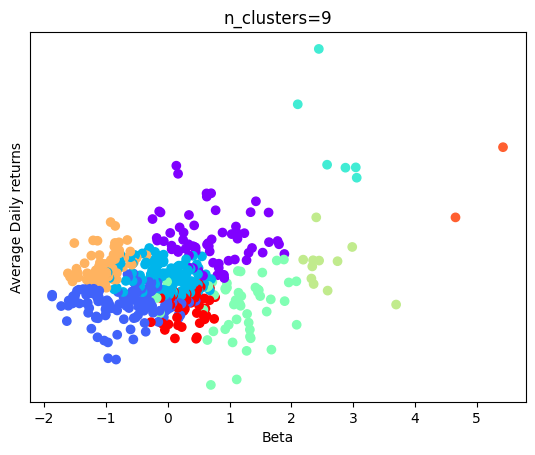

In [53]:
for n_clusters in range_n_clusters:
  model = AgglomerativeClustering(n_clusters=n_clusters)
  labels = model.fit_predict(X)
  plt.scatter(all_dim_scaled['Beta'], all_dim_scaled['Average Daily returns'], c=labels, cmap='rainbow')
  plt.xlabel('Beta')
  plt.ylabel('Average Daily returns')
  plt.title(f"n_clusters={n_clusters}")
  cluster_counts = np.bincount(labels)
  for i in range(n_clusters):
    print(f"Cluster {i+1} has {cluster_counts[i]} observations")
  plt.yticks([])
  plt.show()

Cluster 1 has 179 observations
Cluster 2 has 321 observations


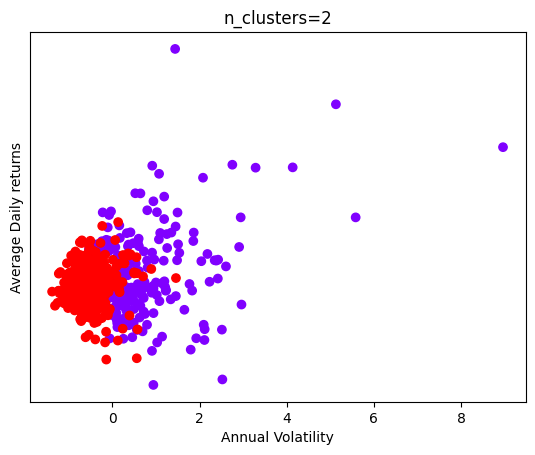

Cluster 1 has 160 observations
Cluster 2 has 321 observations
Cluster 3 has 19 observations


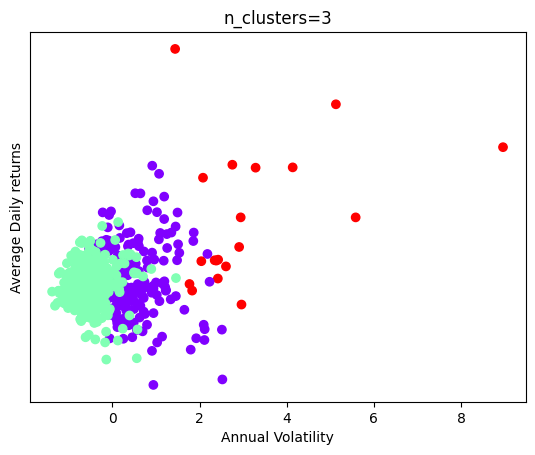

Cluster 1 has 321 observations
Cluster 2 has 95 observations
Cluster 3 has 19 observations
Cluster 4 has 65 observations


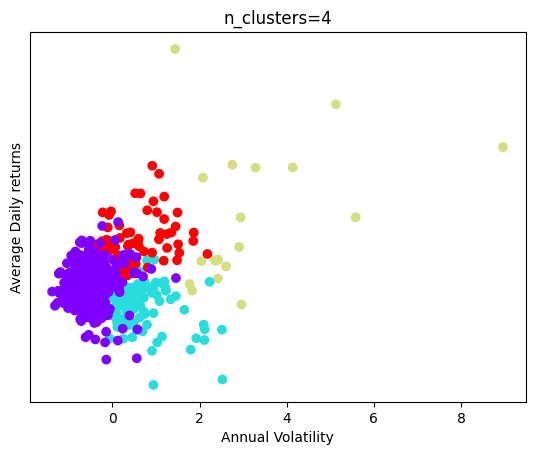

Cluster 1 has 19 observations
Cluster 2 has 95 observations
Cluster 3 has 182 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations


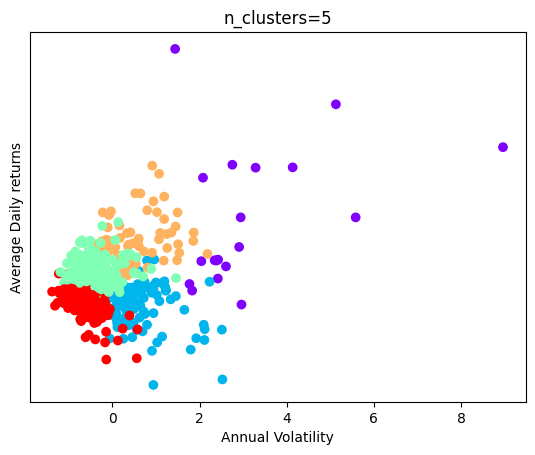

Cluster 1 has 182 observations
Cluster 2 has 95 observations
Cluster 3 has 8 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations


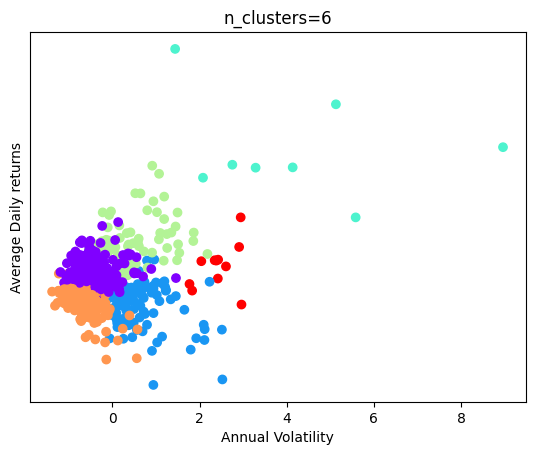

Cluster 1 has 8 observations
Cluster 2 has 95 observations
Cluster 3 has 119 observations
Cluster 4 has 65 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations


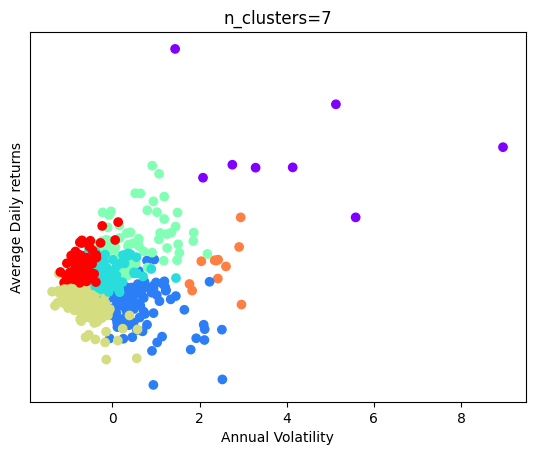

Cluster 1 has 95 observations
Cluster 2 has 65 observations
Cluster 3 has 119 observations
Cluster 4 has 6 observations
Cluster 5 has 139 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations
Cluster 8 has 2 observations


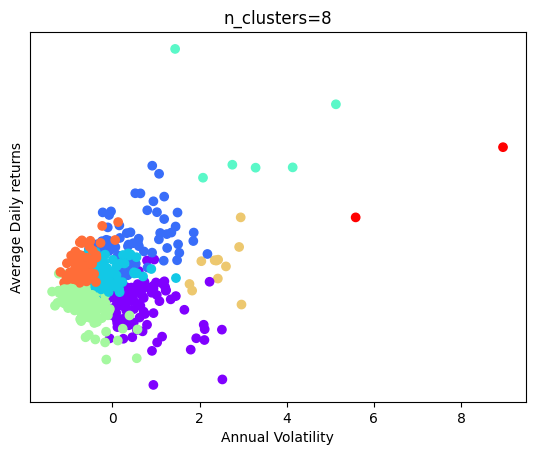

Cluster 1 has 65 observations
Cluster 2 has 139 observations
Cluster 3 has 119 observations
Cluster 4 has 6 observations
Cluster 5 has 50 observations
Cluster 6 has 11 observations
Cluster 7 has 63 observations
Cluster 8 has 2 observations
Cluster 9 has 45 observations


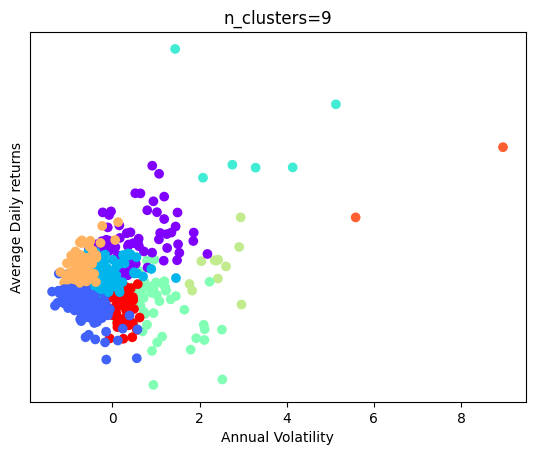

In [54]:
for n_clusters in range_n_clusters:
  model = AgglomerativeClustering(n_clusters=n_clusters)
  labels = model.fit_predict(X)
  plt.scatter(all_dim_scaled['Annual Volatility'], all_dim_scaled['Average Daily returns'], c=labels, cmap='rainbow')
  plt.xlabel('Annual Volatility')
  plt.ylabel('Average Daily returns')
  plt.title(f"n_clusters={n_clusters}")
  cluster_counts = np.bincount(labels)
  for i in range(n_clusters):
    print(f"Cluster {i+1} has {cluster_counts[i]} observations")
  plt.yticks([])
  plt.show()

In [57]:
optimal_n_clusters = 5
agglom = AgglomerativeClustering(n_clusters=optimal_n_clusters)
cluster_labels = agglom.fit_predict(all_dim_scaled[['Beta','Annual Volatility', 'Average Daily returns']])
all_dim_scaled['Cluster'] = cluster_labels
all_dim_scaled

,Ticker,Beta,Annual Volatility,Average Daily returns,Cluster
88,CVNA,5.424153,8.963470,3.965134,0
118,COIN,4.655234,5.582665,1.888782,0
67,XYZ,3.694574,2.962982,-0.689055,0
344,NVDA,3.056861,2.080083,3.062127,0
40,APP,3.041665,4.137818,3.367853,0
...,...,...,...,...,...
292,LMT,-1.616662,-0.916431,0.233378,2
238,HRL,-1.633415,-0.714965,-1.178757,4
414,SJM,-1.725787,-0.825062,-0.733600,4
83,CPB,-1.871037,-0.797777,-0.399988,4


/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


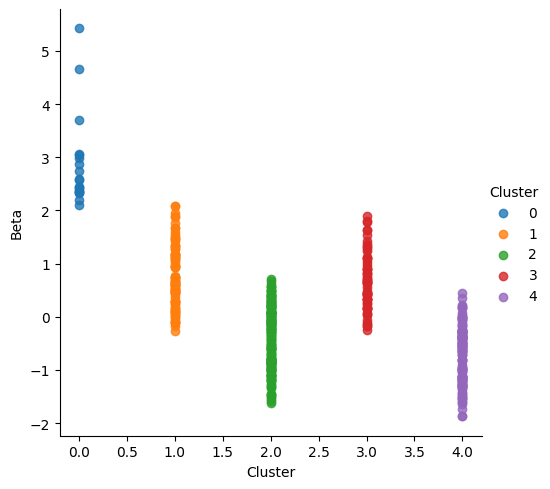

In [58]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='Cluster', y='Beta', hue='Cluster',
legend=True, legend_out=True);

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


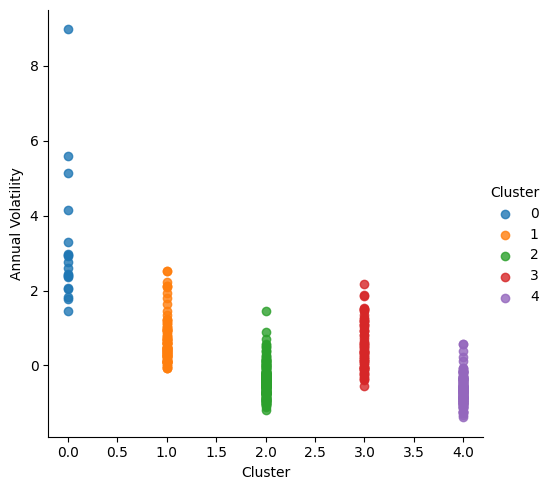

In [59]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='Cluster', y='Annual Volatility', hue='Cluster',
legend=True, legend_out=True);

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


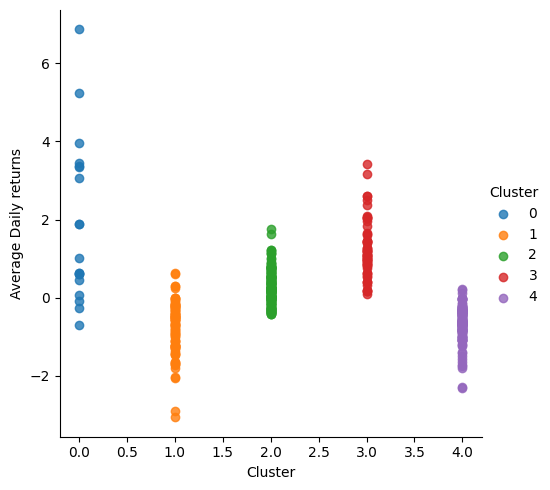

In [60]:
import seaborn as sns
cluster5 = sns.lmplot(data=all_dim_scaled, x='Cluster', y='Average Daily returns', hue='Cluster',
legend=True, legend_out=True);

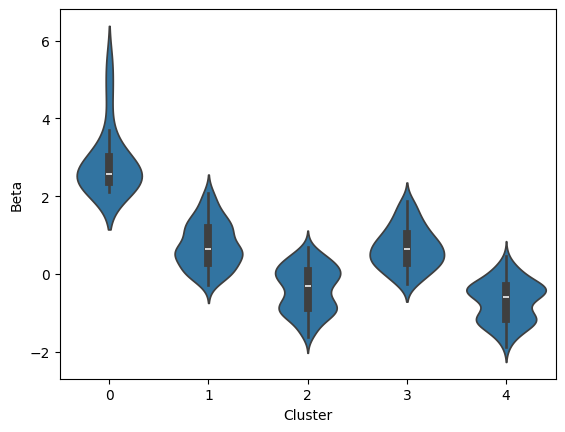

In [61]:
sns.violinplot(x='Cluster', y='Beta', data=all_dim_scaled)
plt.show()

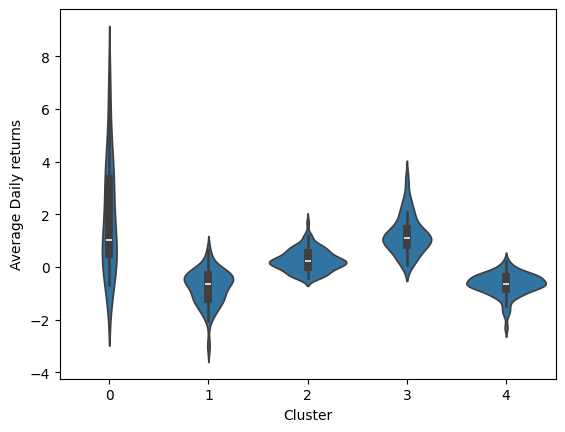

In [62]:
sns.violinplot(x='Cluster', y='Average Daily returns', data=all_dim_scaled)
plt.show()

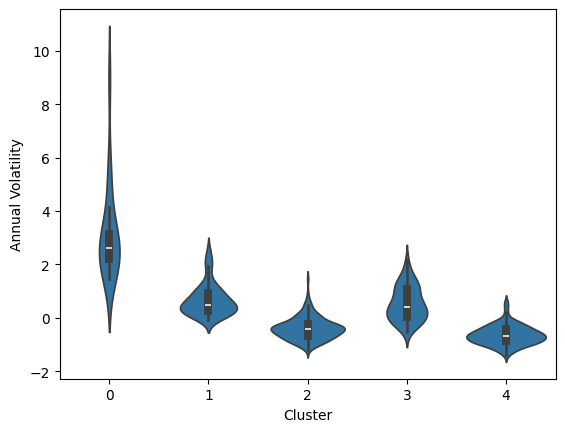

In [64]:
sns.violinplot(x='Cluster', y='Annual Volatility', data=all_dim_scaled)
plt.show()

In [65]:
X = daily_returns
#testing number of cluster from 2 to 10 and collecting the silhouette
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for n_clusters in range_n_clusters:
  agglom = AgglomerativeClustering(n_clusters=n_clusters)
  agglom.fit(X)
  labels = agglom.labels_
  scores.append(silhouette_score(X, labels))
#looking at the scores, and their average/mean
scores
average = sum(scores)/len(scores)
average
#graphing
plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show

ValueError: Input X contains NaN.
AgglomerativeClustering does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values